# deeptrack.backend.mie

<a href="https://colab.research.google.com/github/DeepTrackAI/DeepTrack2/blob/develop/tutorials/3-advanced-topics/DTAT395_backend.mie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# !pip install deeptrack  # Uncomment if running on Colab/Kaggle.

This advanced tutorial introduces the module [deeptrack.backend.mie](../../deeptrack/backend/mie.py).

## 1. What is `mie`?

The `mie` module provides functions to perform Mie scattering calculations, including computation of spherical harmonics coefficients and related operations.

## 2. Calculate Mie Coefficients for a Solid Particle


In [ ]:
from deeptrack.backend import mie

particle_radius = 0.5
relative_refract_index = 1.5 + 0.01j
max_order = 5

A, B = mie.coefficients(relative_refract_index, particle_radius, max_order)

print("A coefficients:", A)
print("B coefficients:", B)

A coefficients: [1.04581094e-03-2.45891920e-02j 5.61754632e-06-3.39444972e-04j
 3.54498410e-08-2.25608771e-06j 1.33314410e-10-8.61596363e-09j
 3.25668489e-13-2.12414217e-11j]
B coefficients: [2.22095481e-05-8.65285036e-04j 1.48987829e-07-6.11710129e-06j
 5.86860069e-10-2.42490110e-08j 1.47867923e-12-6.12742871e-11j
 2.58354155e-15-1.07228248e-13j]


## 2. Calculate Mie Coefficients for a Stratified Particle
Here we only need to specify multiple radii for the different shells of the stratified particle.

In [ ]:
particle_radii = [0.5, 0.6, 0.7]
relative_refract_index = [1.5 + 0.01j, 1.3 + 0.02j, 1.1 + 0.03j]
max_order = 5

A, B = mie.stratified_coefficients(
    relative_refract_index,
    particle_radii,
    max_order,
)

print("A coefficients:", A)
print("B coefficients:", B)

A coefficients: [4.51815568e-03-4.14667025e-02j 9.00848393e-05-8.90449307e-04j
 1.30191942e-06-9.70936049e-06j 1.04767670e-08-6.35738175e-08j
 5.30930040e-11-2.77931029e-10j]
B coefficients: [2.08384699e-04-1.97056962e-03j 2.98780924e-06-2.15999592e-05j
 2.41258487e-08-1.40444143e-07j 1.22573034e-10-6.07956361e-10j
 4.27642496e-13-1.88504769e-12j]


## 3. Calculate Spherical Harmonics of the Mie Field 

(5, 100)
(5, 100)


(-0.5, 99.5, 4.5, -0.5)

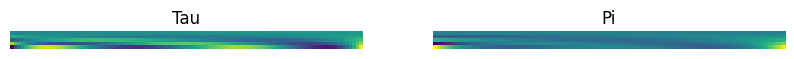

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

x = np.linspace(-1, 1, 100)
L = 5
pi, tau = mie.harmonics(x, L)

print(pi.shape)
print(tau.shape)

fig, axes = plt.subplots(1, 2, figsize=(10, 10))

axes[0].imshow(tau, cmap="viridis")
axes[0].set_title("Tau")
axes[0].axis("off")

axes[1].imshow(pi, cmap="viridis")
axes[1].set_title("Pi")
axes[1].axis("off")